# Data Analysis for Book Recommender
*2026-04*

In [40]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from src.main import load_books_dataset, build_tfidf, recommend_tfidf, preprocess

In [41]:
df = load_books_dataset()
print(f'Dataset loaded: {df.shape[0]:,} books, {df.shape[1]} columns')
df.head(3)

Dataset loaded: 16,559 books, 5 columns


,title,author,genres,summary,combined
0,Animal Farm,George Orwell,"Roman à clef, Satire, Children's literature, S...","Old Major, the old boar on the Manor Farm, ca...",roman clef satire children s literature specul...
1,A Clockwork Orange,Anthony Burgess,"Science Fiction, Novella, Speculative fiction,...","Alex, a teenager living in near-future Englan...",science fiction novella speculative fiction ut...
2,The Plague,Albert Camus,"Existentialism, Fiction, Absurdist fiction, Novel",The text of The Plague is divided into five p...,existentialism fiction absurdist fiction novel...


## Dataset Analysis

In [42]:
stats = pd.DataFrame({
    'non_null': df.count(),
    'null': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(1),
    'unique': df.nunique(),
})
display(stats)

,non_null,null,null_%,unique
title,16559,0,0.0,16277
author,16559,0,0.0,4715
genres,16559,0,0.0,2155
summary,16559,0,0.0,16532
combined,16559,0,0.0,16549


### Distributions

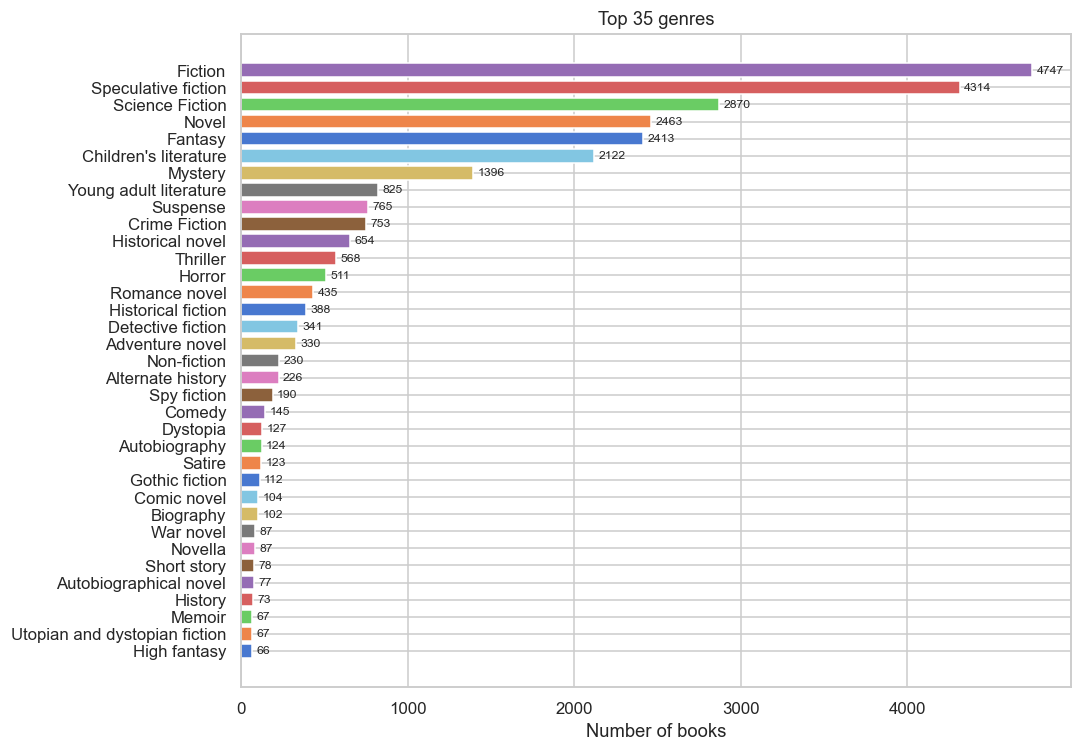

Books with no genre: 3718 (22.5%)


In [43]:
# genre distribution (top 35)
genres_series = (
    df['genres']
    .dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
)

top_genres = genres_series.value_counts().head(35)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=sns.color_palette('muted', 35))
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel('Number of books')
ax.set_title('Top 35 genres')
plt.tight_layout()
plt.show()

no_genre = (df['genres'] == '').sum()
print(f'Books with no genre: {no_genre} ({no_genre/len(df)*100:.1f}%)')

In [44]:
# do i need books without genre for this project?? rethinkkkk

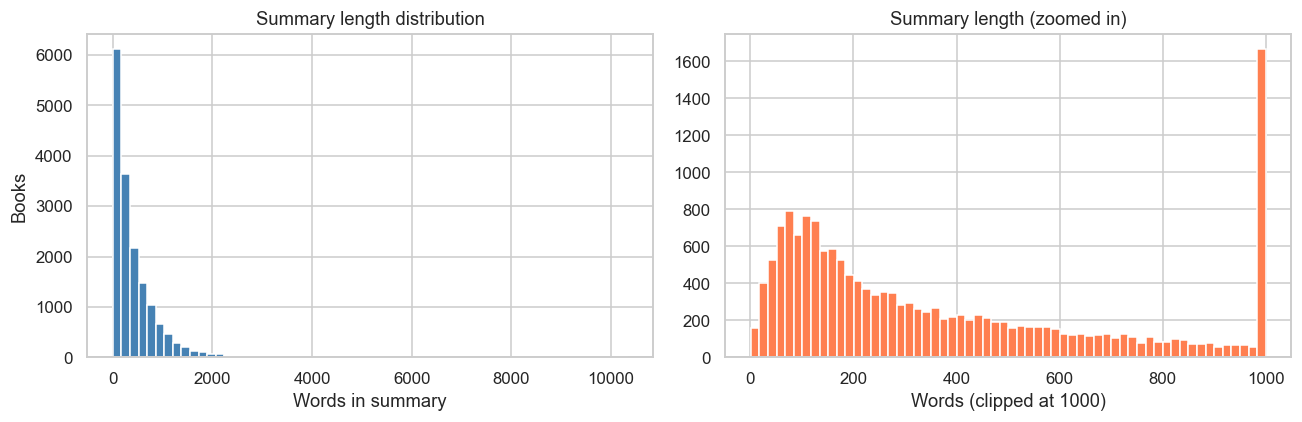

count    16559
mean       429
std        500
min          1
25%        120
50%        263
75%        569
max      10334


In [45]:
# Summary length distribution
df['summary_len'] = df['summary'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['summary_len'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Words in summary')
axes[0].set_ylabel('Books')
axes[0].set_title('Summary length distribution')

axes[1].hist(df['summary_len'].clip(upper=1000), bins=60, color='coral', edgecolor='white')
axes[1].set_xlabel('Words (clipped at 1000)')
axes[1].set_title('Summary length (zoomed in)')

plt.tight_layout()
plt.show()

print(df['summary_len'].describe().round(0).astype(int).to_string())

In [46]:
# rethink: analyze books without summaries (genres) and decide if I want to remove them (6k :_))

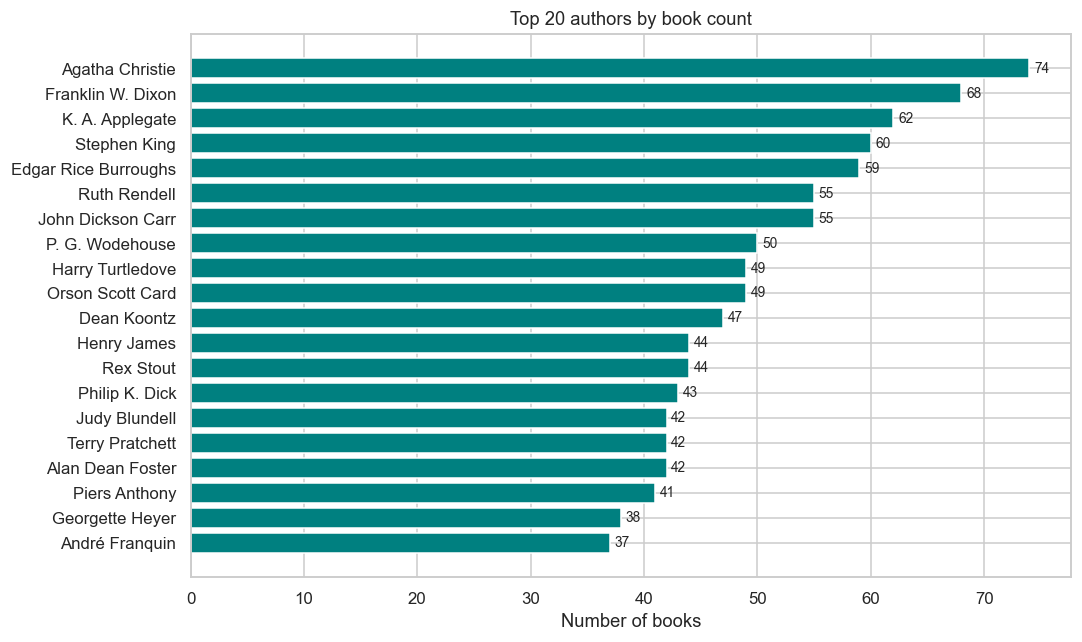

In [47]:
# top authors by book count
top_authors = df[df['author'] != 'Unknown']['author'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_authors.index[::-1], top_authors.values[::-1], color='teal')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of books')
ax.set_title('Top 20 authors by book count')
plt.tight_layout()
plt.show()

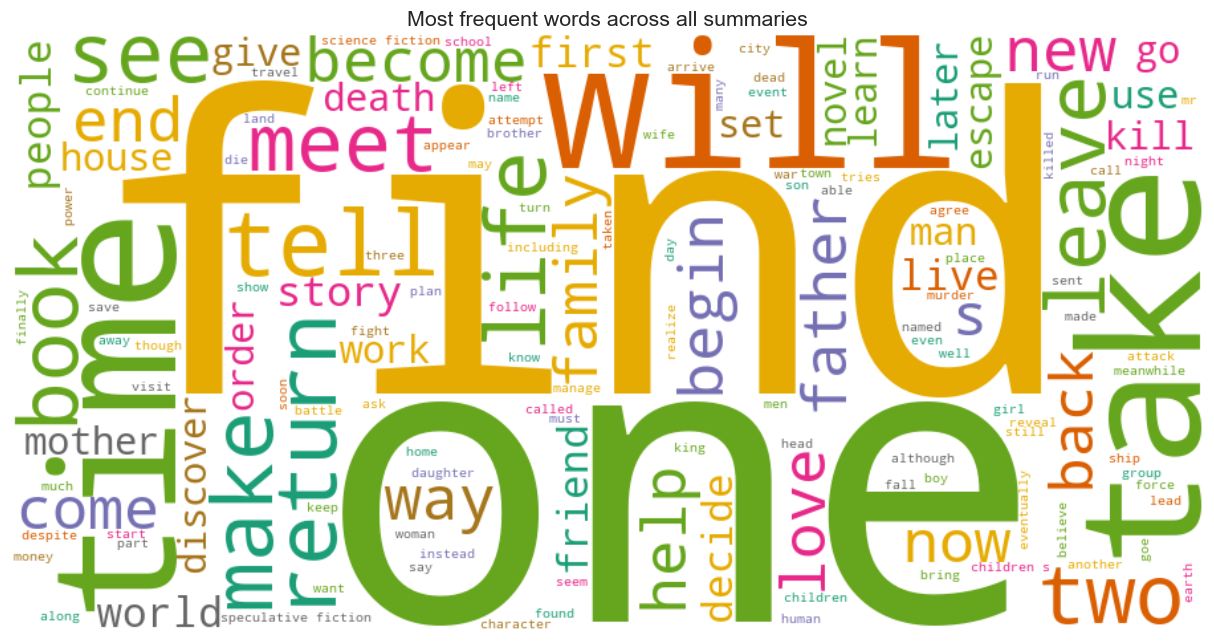

In [48]:
# wordcloud
all_text = ' '.join(df['combined'].dropna())

wc = WordCloud(width=900, height=450, background_color='white',
               max_words=150, colormap='Dark2').generate(all_text)

plt.figure(figsize=(13, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words across all summaries', fontsize=14)
plt.tight_layout()
plt.show()

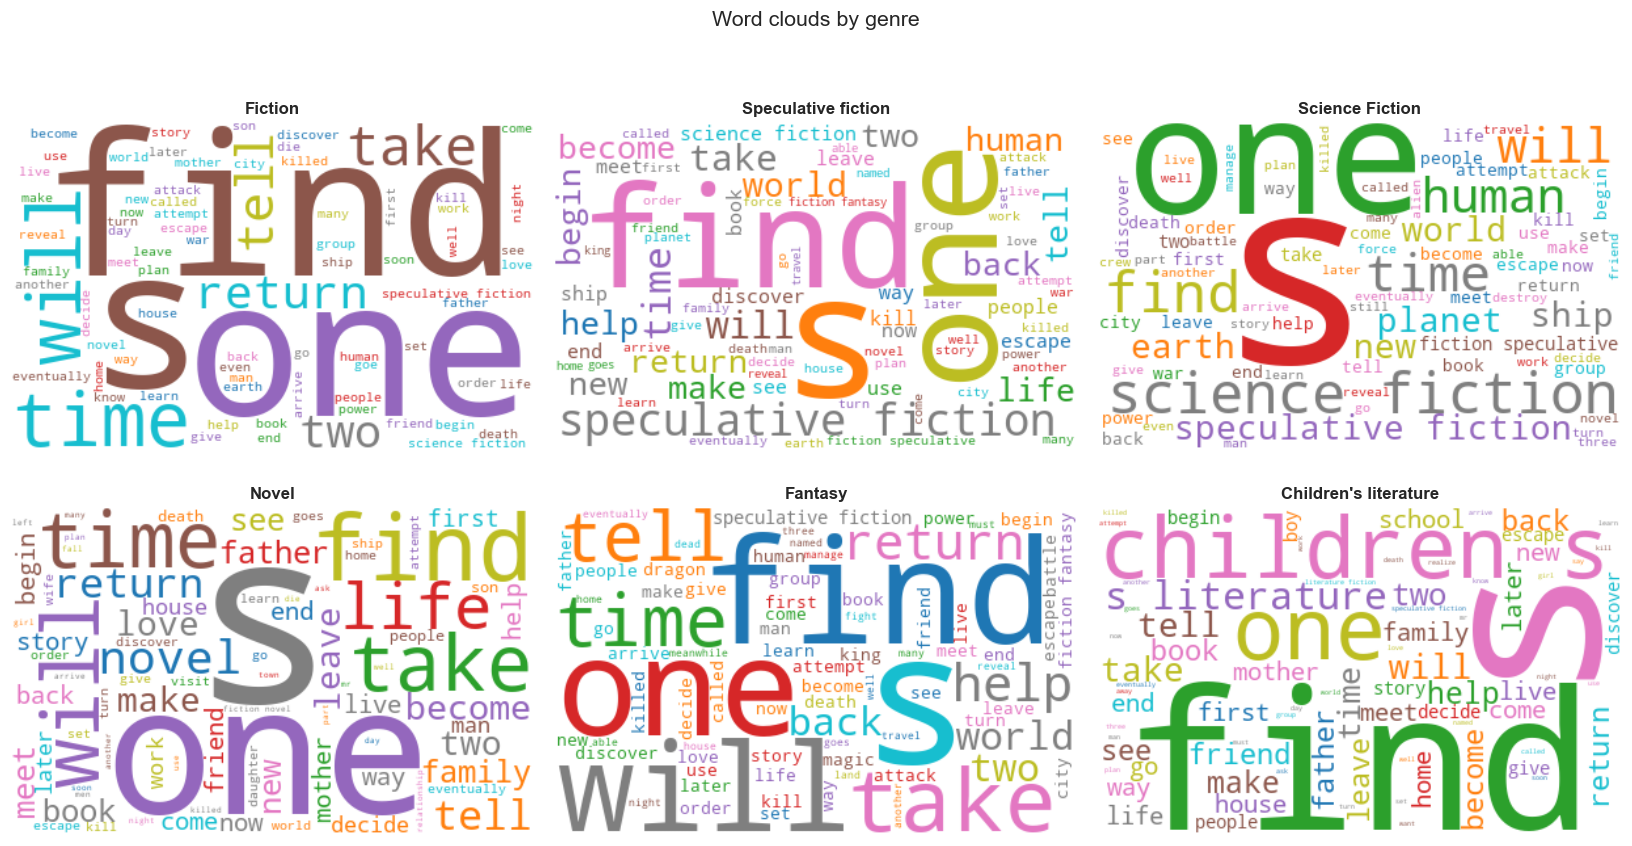

In [49]:
# wordclouds by genre (top 6)
top6_genres = top_genres.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, genre in zip(axes.flatten(), top6_genres):
    mask = df['genres'].str.contains(genre, case=False, na=False)
    text = ' '.join(df[mask]['combined'].dropna())
    if not text.strip():
        ax.axis('off')
        continue
    wc = WordCloud(width=400, height=250, background_color='white',
                   max_words=80, colormap='tab10').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(genre, fontsize=11, fontweight='bold')

plt.suptitle('Word clouds by genre', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [50]:
# S word??? print summaries examples to see that

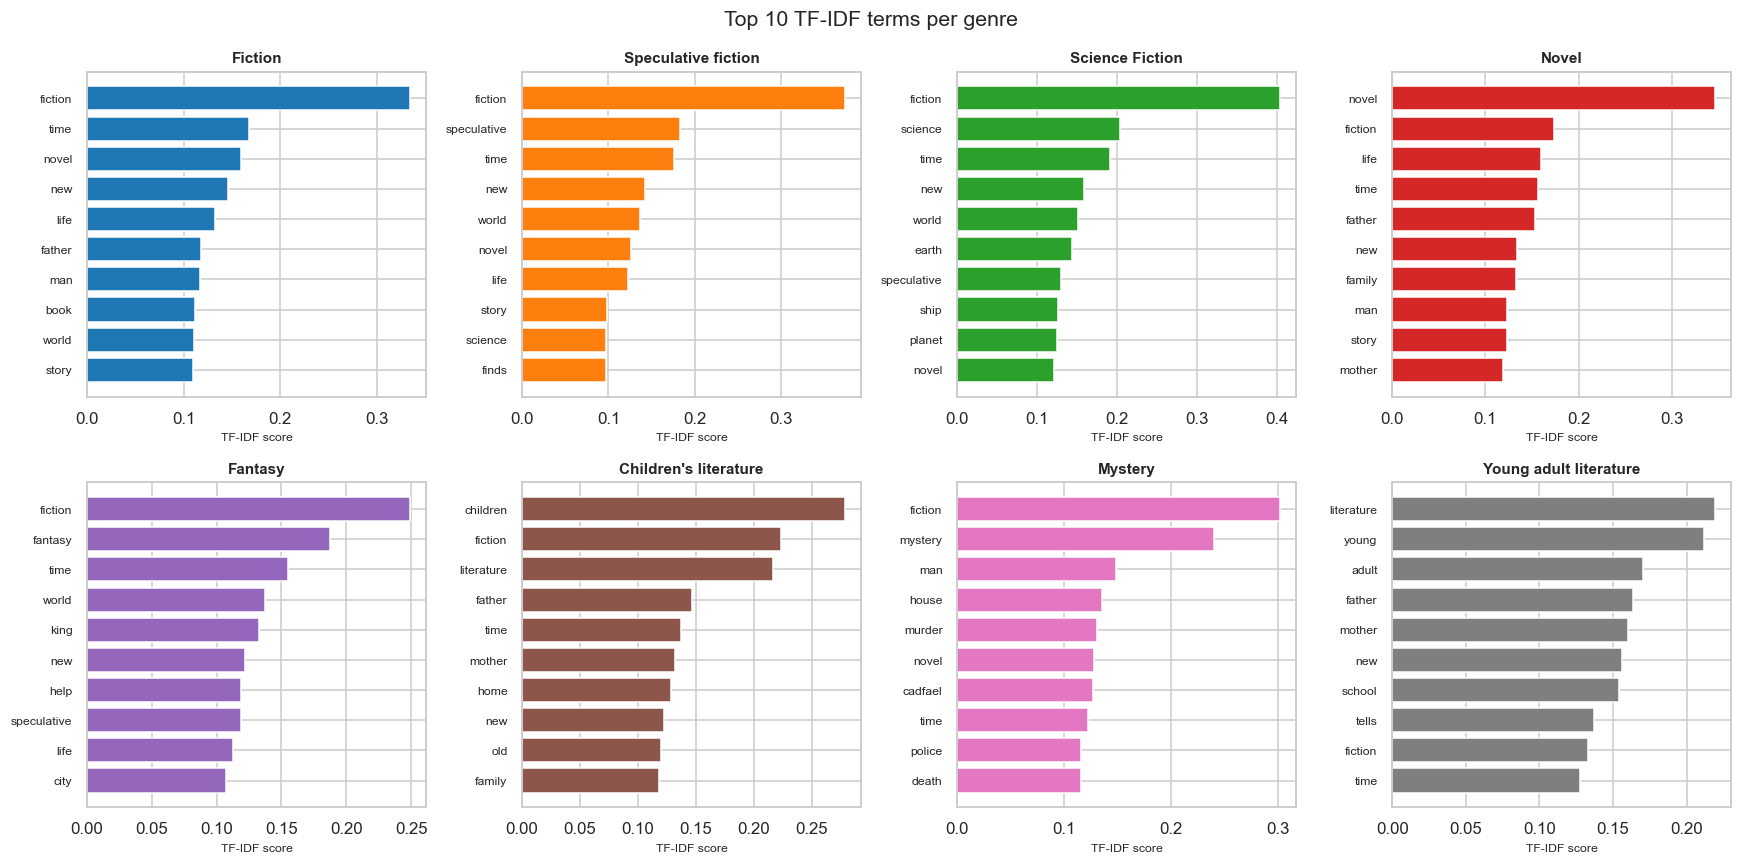

In [51]:
# top TF-IDF terms per genre (which words best characterise each genre, not just frequent but discriminative)

TOP_GENRES_ANALYSIS = top_genres.head(8).index.tolist()
N_TERMS = 10

# Build one 'document' per genre by concatenating all summaries
genre_docs = {}
for genre in TOP_GENRES_ANALYSIS:
    mask = df['genres'].str.contains(genre, case=False, na=False)
    genre_docs[genre] = ' '.join(df[mask]['combined'].dropna())

genre_df = pd.DataFrame({'genre': list(genre_docs.keys()), 'text': list(genre_docs.values())})

tv = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,1))
genre_matrix = tv.fit_transform(genre_df['text'])
feature_names = tv.get_feature_names_out()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
colors = sns.color_palette('tab10', len(TOP_GENRES_ANALYSIS))

for idx, (ax, genre) in enumerate(zip(axes.flatten(), TOP_GENRES_ANALYSIS)):
    row = genre_matrix[idx].toarray().flatten()
    top_idx = row.argsort()[-N_TERMS:][::-1]
    terms = feature_names[top_idx]
    scores = row[top_idx]
    ax.barh(terms[::-1], scores[::-1], color=colors[idx])
    ax.set_title(genre, fontsize=10, fontweight='bold')
    ax.set_xlabel('TF-IDF score', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f'Top {N_TERMS} TF-IDF terms per genre', fontsize=14)
plt.tight_layout()
plt.show()

## TF-IDF Recommender Analysis

In [52]:
vectorizer, book_vectors = build_tfidf(df)
print(f'Vocabulary size: {len(vectorizer.vocabulary_):,} terms')

Vocabulary size: 354,684 terms


In [53]:
# compare queries: scores side by side
QUERIES = [
    'romance war', # short keywords
    'romance book with scenes of war', # natural language
    'love story world war historical fiction', # enriched keywords
    'science fiction space exploration adventure',
    'mystery detective crime murder london',
    'fantasy magic dragons quest',
    'horror supernatural ghost haunted',
    'coming of age school friendship',
]

TOP_N = 5
results = {}
for q in QUERIES:
    res = recommend_tfidf(q, TOP_N, df, vectorizer, book_vectors)
    results[q] = res

# show results in a readable format
for q, res in results.items():
    print(f"\n{'─'*70}")
    print(f"Query: '{q}'")
    print(f"Max score: {res['score'].max():.3f}  |  Mean score: {res['score'].mean():.3f}")
    display(res[['title', 'genres', 'score']].to_string(index=False))


──────────────────────────────────────────────────────────────────────
Query: 'romance war'
Max score: 0.267  |  Mean score: 0.125


'               title                                                        genres  score\n      This Above All                   Chivalric romance, War novel, Romance novel  0.267\n           The March                                   Historical fiction, Fiction  0.110\nThe Eyes of Darkness Speculative fiction, Horror, Fiction, Romance novel, Suspense  0.099\n         Angel Light   Speculative fiction, Fantasy, Fiction, Romance novel, Novel  0.078\n          L’Opoponax                                                         Novel  0.070'


──────────────────────────────────────────────────────────────────────
Query: 'romance book with scenes of war'
Max score: 0.105  |  Mean score: 0.088


'                 title                                                                                                                        genres  score\n          Deadeye Dick                                                                                                    Speculative fiction, Novel  0.105\n       The Golden Lily                                                                     Urban fantasy, Young adult literature, Paranormal romance  0.095\n       Succubus on Top Urban fantasy, Speculative fiction, Young adult literature, Romance novel, Mystery, Fantasy, Dark fantasy, Paranormal romance  0.087\nThe Monkey Wrench Gang                                                                                           Speculative fiction, Fiction, Novel  0.080\n  The Eyes of Darkness                                                                 Speculative fiction, Horror, Fiction, Romance novel, Suspense  0.072'


──────────────────────────────────────────────────────────────────────
Query: 'love story world war historical fiction'
Max score: 0.114  |  Mean score: 0.096


...

'             title                                           genres  score\n       Dragoncharm            Speculative fiction, Fantasy, Fiction  0.174\nThe Dragon Society            Speculative fiction, Fantasy, Fiction  0.134\n      Dragon Venom            Speculative fiction, Fantasy, Fiction  0.124\n    Tooth and Claw Fantasy of manners, Speculative fiction, Fantasy  0.113\n  The Lady Decides                                          Fantasy  0.109'


──────────────────────────────────────────────────────────────────────
Query: 'horror supernatural ghost haunted'
Max score: 0.192  |  Mean score: 0.157


"                       title                                                                                     genres  score\nThe Case of the Cursed Clock                                                                                             0.192\n                The Haunting              Ghost story, Speculative fiction, Children's literature, Fiction, Low fantasy  0.176\n            Guilty Pleasures Horror, Supernatural, Speculative fiction, Mystery, Fantasy, Fiction, Hardboiled, Suspense  0.159\n              Skeleton Creek                                                                                             0.131\n                        Lost                                                      Mystery, Speculative fiction, Fiction  0.127"


──────────────────────────────────────────────────────────────────────
Query: 'coming of age school friendship'
Max score: 0.195  |  Mean score: 0.169


'                                     title                                    genres  score\n                           The Last Wizard                                   Fantasy  0.195\n                     A Posse of Princesses              Speculative fiction, Fantasy  0.193\nDon Rodriguez: Chronicles of Shadow Valley Fantasy, Speculative fiction, Short story  0.158\n                      No Place for Grubbs!                                            0.153\n                  Montecore: en unik tiger                                            0.146'

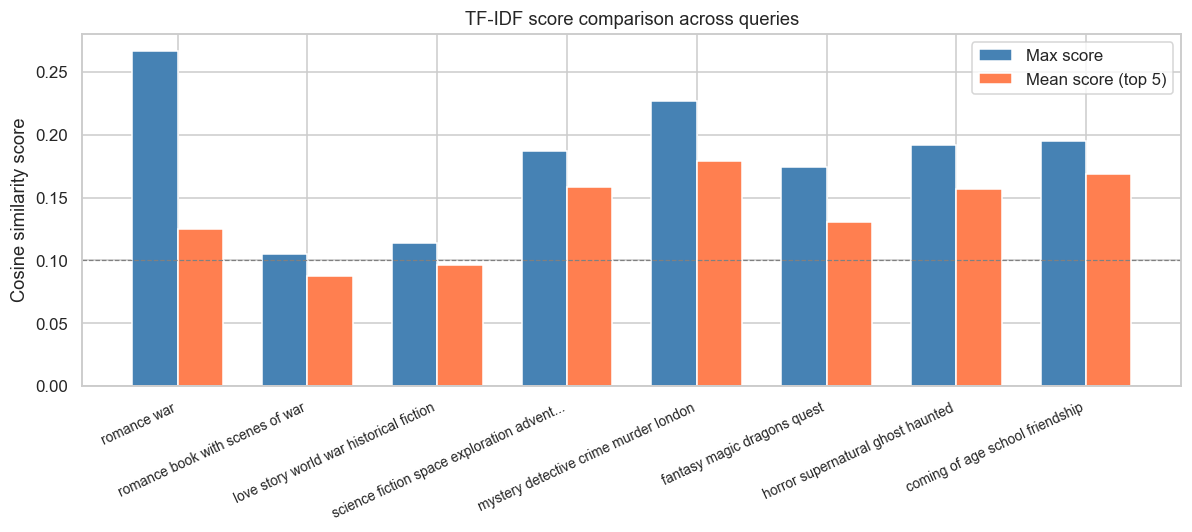

In [54]:
# score comparison chart across queries
summary_data = []
for q, res in results.items():
    summary_data.append({
        'query': q[:40] + ('...' if len(q) > 40 else ''),
        'max_score': res['score'].max(),
        'mean_score': res['score'].mean(),
    })
summary_df = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summary_df))
width = 0.35
ax.bar(x - width/2, summary_df['max_score'], width, label='Max score', color='steelblue')
ax.bar(x + width/2, summary_df['mean_score'], width, label='Mean score (top 5)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['query'], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Cosine similarity score')
ax.set_title('TF-IDF score comparison across queries')
ax.legend()
ax.axhline(0.1, color='gray', linestyle='--', linewidth=0.8, label='0.1 threshold')
plt.tight_layout()
plt.show()

# low tfidf scores in general

In [55]:
# what terms in the query actually matched?
# which query tokens exist in the TF-IDF vocabulary (and which are ignored).

vocab = set(vectorizer.vocabulary_.keys())

for q in QUERIES[:4]:  # limit to first 4 for readability
    tokens = preprocess(q).split()
    matched = [t for t in tokens if t in vocab]
    missed  = [t for t in tokens if t not in vocab]
    print(f"Query : '{q}'")
    print(f"  In vocab  : {matched}")
    print(f"  Not found : {missed}")
    print()

Query : 'romance war'
  In vocab  : ['romance', 'war']
  Not found : []

Query : 'romance book with scenes of war'
  In vocab  : ['romance', 'book', 'scenes', 'war']
  Not found : ['with', 'of']

Query : 'love story world war historical fiction'
  In vocab  : ['love', 'story', 'world', 'war', 'historical', 'fiction']
  Not found : []

Query : 'science fiction space exploration adventure'
  In vocab  : ['science', 'fiction', 'space', 'exploration', 'adventure']
  Not found : []



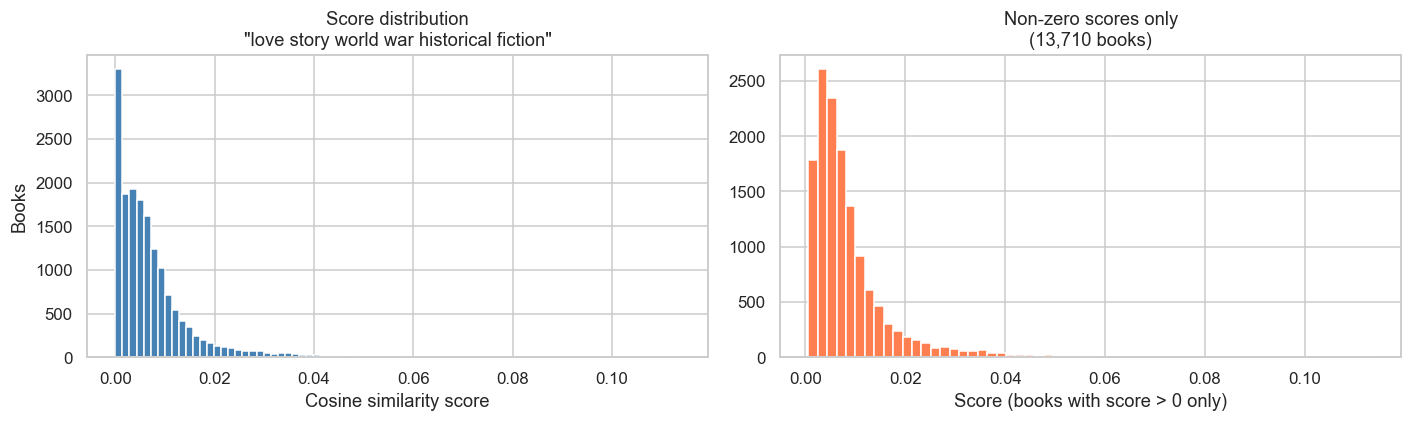

Books with score = 0 : 2,849 (17.2%)
Books with score > 0 : 13,710
Books with score > 0.1: 2


In [56]:
# score distribution for a specific query
FOCUS_QUERY = 'love story world war historical fiction'

query_vec = vectorizer.transform([preprocess(FOCUS_QUERY)])
all_scores = cosine_similarity(query_vec, book_vectors).flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(all_scores, bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Cosine similarity score')
axes[0].set_ylabel('Books')
axes[0].set_title(f'Score distribution\n"{FOCUS_QUERY}"')

axes[1].hist(all_scores[all_scores > 0], bins=60, color='coral', edgecolor='white')
axes[1].set_xlabel('Score (books with score > 0 only)')
axes[1].set_title(f'Non-zero scores only\n({(all_scores > 0).sum():,} books)')

plt.tight_layout()
plt.show()

print(f'Books with score = 0 : {(all_scores == 0).sum():,} ({(all_scores == 0).mean()*100:.1f}%)')
print(f'Books with score > 0 : {(all_scores > 0).sum():,}')
print(f'Books with score > 0.1: {(all_scores > 0.1).sum():,}')

In [57]:
# do romance + war books exist in the dataset?

has_romance = df['genres'].str.contains('romance', case=False, na=False)
has_war     = df['summary'].str.contains(r'\bwar\b', case=False, na=False)

both = df[has_romance & has_war][['title', 'author', 'genres', 'summary']]
print(f'Books with romance genre AND war in summary: {len(both)}')
display(both[['title', 'author', 'genres']].head(15))

Books with romance genre AND war in summary: 61


,title,author,genres
78,The Lord of the Rings,J. R. R. Tolkien,"Adventure novel, Speculative fiction, Fantasy,..."
298,Dune,Frank Herbert,"Conspiracy fiction, Science Fiction, Philosoph..."
376,Island of the Sequined Love Nun,Christopher Moore,"Speculative fiction, Comedy, Romance novel"
385,A Room with a View,E. M. Forster,"Travel, Fiction, Romance novel, Novel"
426,War and Peace,Leo Tolstoy,"War novel, Romance novel, Historical novel"
515,Lady Chatterley's Lover,D. H. Lawrence,"Erotica, Romance novel"
698,From the Earth to the Moon,Jules Verne,"Science Fiction, Speculative fiction, Novel, S..."
710,Captain Corelli's Mandolin,Louis de Bernières,"War novel, Romance novel, Historical novel"
894,Persuasion,Jane Austen,"Novel, Children's literature, Suspense, Romanc..."
1182,Ponniyin Selvan,Kalki Krishnamurthy,"Thriller, Spy fiction, Novel, Romance novel, H..."
